# Homework 02: Multi-Class Classification with Neural Networks

#### Due Date: Sunday, September 13th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus. 

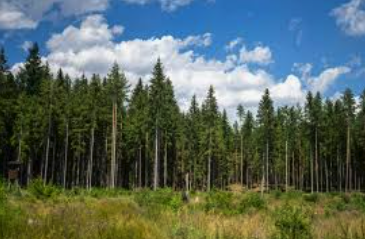

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance. 

Finally, you will consider all that you have learned and build your best model and run it on the test set. 


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework. 


In [1]:
# Useful imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

random_seed = 42

tf.random.set_seed(random_seed)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

In [2]:
# Utility function: Plotting Training Loss (categorical x-entropy) and Accuracy

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')

## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples. 

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

# Load
X, y = fetch_covtype(return_X_y=True)   # y in {1..7}
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()                # size of rarest class (~2.7k)

# Build perfectly balanced subset (no replacement, no duplicates)
rng = np.random.default_rng(42)
idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = X[idx_bal]
y_sub = y[idx_bal] - 1                  # relabel to 0..6 for Keras
print("Subset shape:", X_sub.shape, "Class counts:", Counter(y_sub))


Subset shape: (19229, 54) Class counts: Counter({np.int32(3): 2747, np.int32(2): 2747, np.int32(6): 2747, np.int32(5): 2747, np.int32(4): 2747, np.int32(1): 2747, np.int32(0): 2747})


## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these three steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify=y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size=0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [4]:
# Perform train-test split, keeping both stratified, then standardize

X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, stratify=y_sub, test_size=0.2, random_state=random_seed)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



In [6]:
# Your code here

model_baseline = Sequential(
    [
       Input(shape=(X_train.shape[1],)),     # Explicit input layer
       Dense(64, activation="relu"),
       Dense(32, activation="relu"),
       Dense(len(classes), activation='softmax') # 1 neuron per unique class since softmax outputs a probability distribution
    ]
)

In [7]:
model_baseline.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
n_epochs = 20
batch_size = 32

In [10]:
model_baseline_history = model_baseline.fit(
    X_train_scaled, 
    y_train,
    epochs=n_epochs,
    batch_size=batch_size
)

Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - accuracy: 0.3600 - loss: 1.7596
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - accuracy: 0.5630 - loss: 1.2726
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - accuracy: 0.6024 - loss: 1.0382
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.6282 - loss: 0.9342
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - accuracy: 0.6504 - loss: 0.8784
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.6646 - loss: 0.8422
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.6728 - loss: 0.8163
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step - accuracy: 0.6817 - loss: 0.7962
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.6870 - loss: 0.7794
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.6930 - loss: 0.7651
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.6986 - loss: 0.7525
Epoch 12/20
481/481 ━━━━━━━━━━

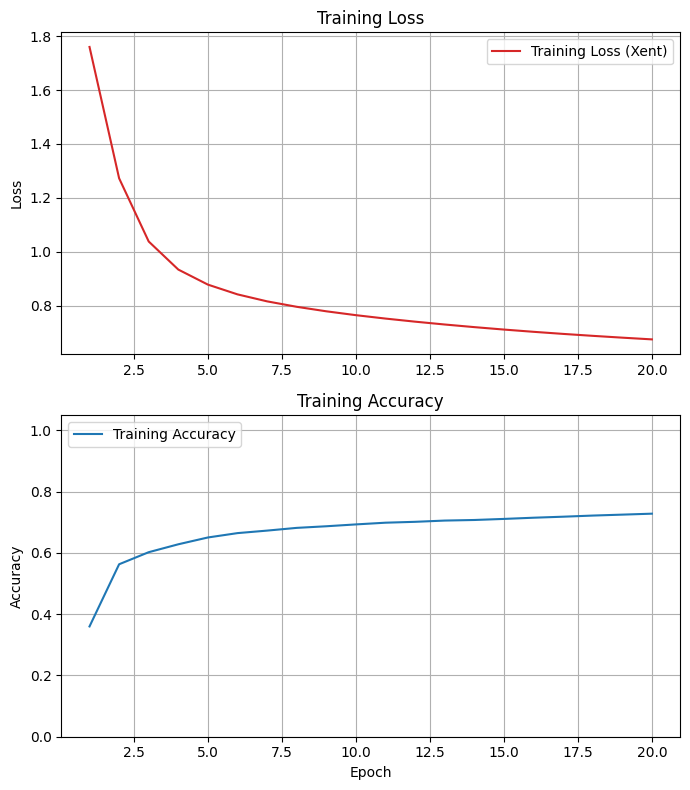

Final Training Loss:     0.6753
Final Training Accuracy: 0.7281


In [11]:
plot_history(model_baseline_history)

In [12]:
# Set a1a to the final training accuracy at epoch 20

a1a = model_baseline_history.history['accuracy'][-1]             # Replace 0.0 with your answer

In [13]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')  

a1a = 0.7281


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!

Epoch 1/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 3s 577us/step - accuracy: 0.5131 - loss: 1.2950
Epoch 2/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 603us/step - accuracy: 0.6443 - loss: 0.8704
Epoch 3/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 583us/step - accuracy: 0.6750 - loss: 0.7910
Epoch 4/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 569us/step - accuracy: 0.6912 - loss: 0.7465
Epoch 5/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 578us/step - accuracy: 0.7066 - loss: 0.7140
Epoch 6/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 568us/step - accuracy: 0.7183 - loss: 0.6889
Epoch 7/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 579us/step - accuracy: 0.7288 - loss: 0.6683
Epoch 8/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 563us/step - accuracy: 0.7375 - loss: 0.6508
Epoch 9/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 571us/step - accuracy: 0.7409 - loss: 0.6358
Epoch 10/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 566us/step - accuracy: 0.7463 - loss: 0.6230
Epoch 11/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 572us/step - accuracy: 0.7517 - loss: 0.6121
Epoch 12

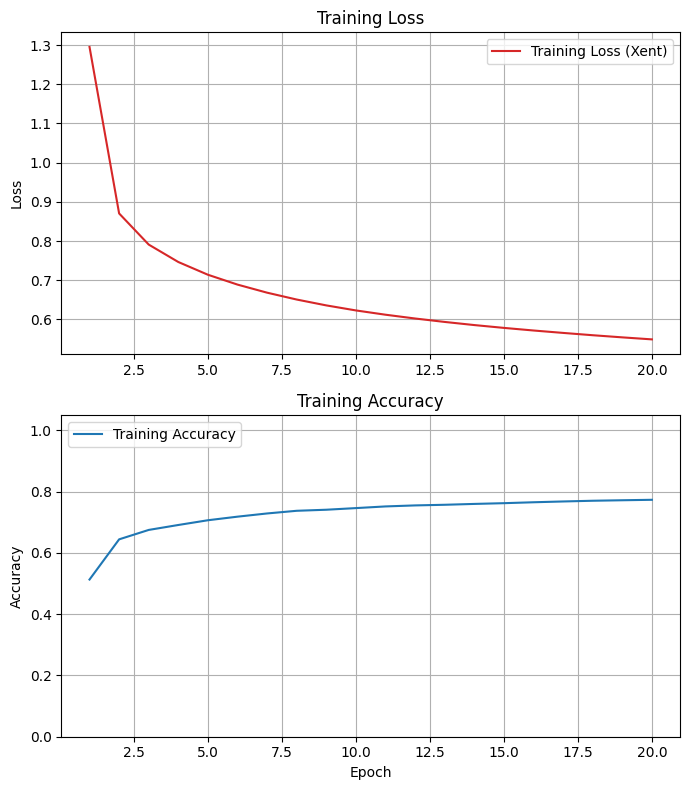

Final Training Loss:     0.5492
Final Training Accuracy: 0.7734
Epoch 1/20
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 1s 574us/step - accuracy: 0.4557 - loss: 1.4649
Epoch 2/20
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 1s 571us/step - accuracy: 0.6145 - loss: 0.9837
Epoch 3/20
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 1s 601us/step - accuracy: 0.6515 - loss: 0.8680
Epoch 4/20
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 1s 596us/step - accuracy: 0.6706 - loss: 0.8174
Epoch 5/20
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 1s 583us/step - accuracy: 0.6816 - loss: 0.7833
Epoch 6/20
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 1s 554us/step - accuracy: 0.6915 - loss: 0.7562
Epoch 7/20
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 1s 572us/step - accuracy: 0.7006 - loss: 0.7329
Epoch 8/20
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 1s 598us/step - accuracy: 0.7089 - loss: 0.7126
Epoch 9/20
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 1s 578us/step - accuracy: 0.7147 - loss: 0.6950
Epoch 10/20
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 1s 597us/step - accuracy: 0.7204 - loss: 0.6798
Epoch 11/20
1923/1923 ━━━━━━━━━━━━━

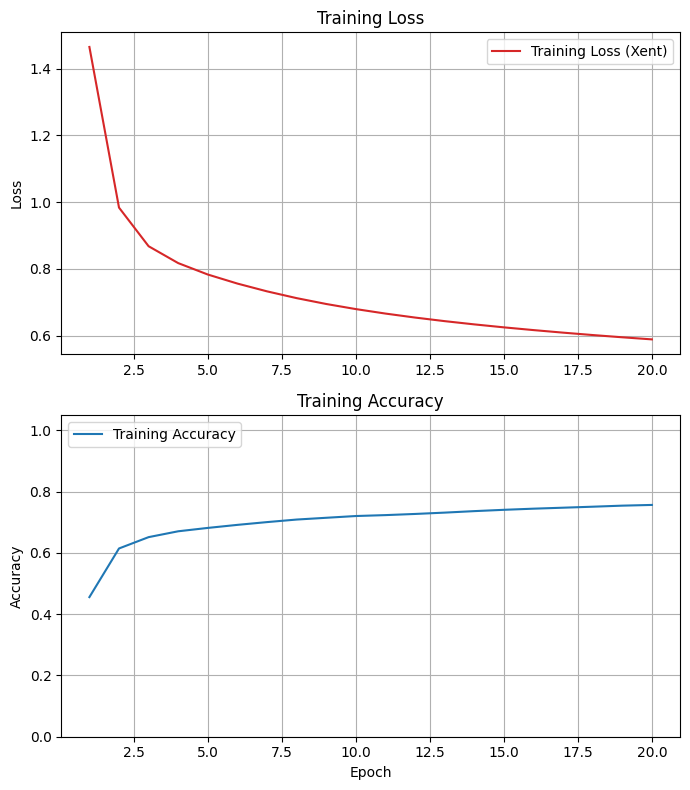

Final Training Loss:     0.5890
Final Training Accuracy: 0.7566
Epoch 1/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 607us/step - accuracy: 0.4406 - loss: 1.6072
Epoch 2/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 621us/step - accuracy: 0.5920 - loss: 1.0726
Epoch 3/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 598us/step - accuracy: 0.6258 - loss: 0.9102
Epoch 4/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 610us/step - accuracy: 0.6577 - loss: 0.8444
Epoch 5/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 593us/step - accuracy: 0.6737 - loss: 0.8064
Epoch 6/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 586us/step - accuracy: 0.6842 - loss: 0.7786
Epoch 7/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 586us/step - accuracy: 0.6929 - loss: 0.7554
Epoch 8/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step - accuracy: 0.7011 - loss: 0.7355
Epoch 9/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 600us/step - accuracy: 0.7077 - loss: 0.7180
Epoch 10/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 587us/step - accuracy: 0.7142 - loss: 0.7020
Epoch 11/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 571us/step 

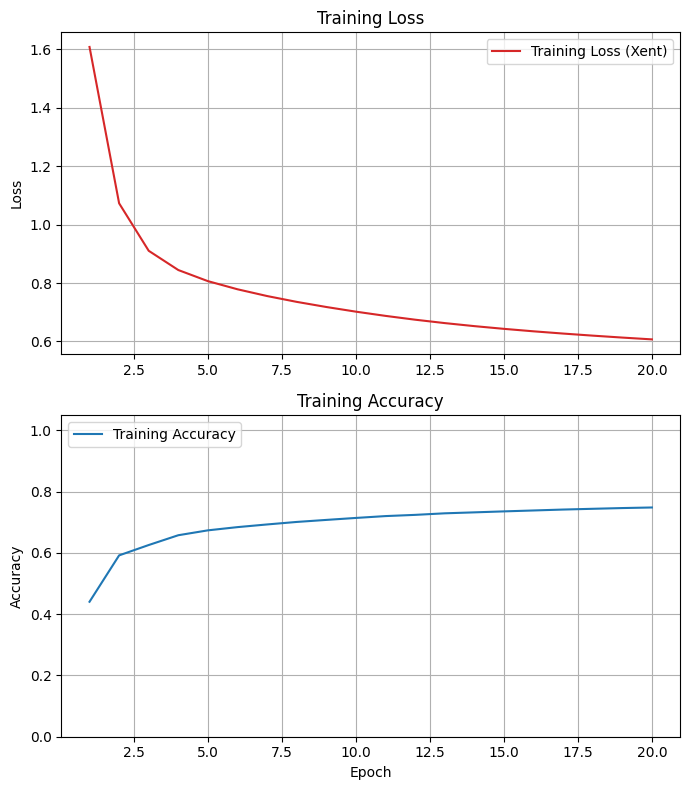

Final Training Loss:     0.6073
Final Training Accuracy: 0.7483
Epoch 1/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - accuracy: 0.2005 - loss: 1.9724
Epoch 2/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - accuracy: 0.3509 - loss: 1.7091
Epoch 3/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - accuracy: 0.4973 - loss: 1.5177
Epoch 4/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - accuracy: 0.5463 - loss: 1.3584
Epoch 5/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step - accuracy: 0.5693 - loss: 1.2277
Epoch 6/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - accuracy: 0.5848 - loss: 1.1252
Epoch 7/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step - accuracy: 0.5965 - loss: 1.0494
Epoch 8/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step - accuracy: 0.6084 - loss: 0.9941
Epoch 9/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step - accuracy: 0.6204 - loss: 0.9530
Epoch 10/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - accuracy: 0.6326 - loss: 0.9213
Epoch 11/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step 

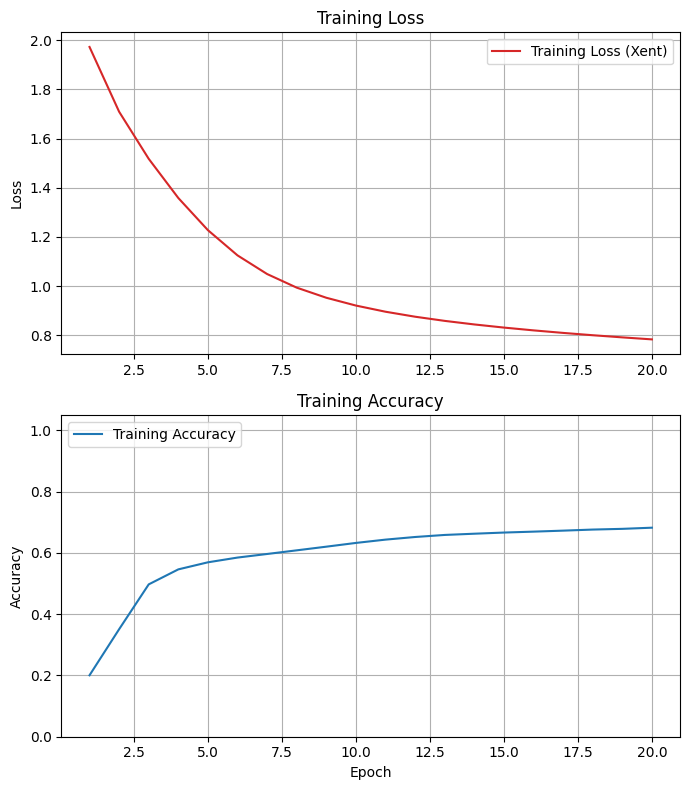

Final Training Loss:     0.7838
Final Training Accuracy: 0.6823


In [14]:
# Your code here
batch_sizes = [4, 8, 16, 128]
final_epoch_training_acc = []
for b in batch_sizes:
    model_baseline = Sequential(
        [
        Input(shape=(X_train.shape[1],)),     # Explicit input layer
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(len(classes), activation='softmax') # 1 neuron per unique class since softmax outputs a probability distribution
        ]
    )
    model_baseline.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model_baseline_history = model_baseline.fit(
        X_train_scaled, 
        y_train,
        epochs=n_epochs,
        batch_size=b
    )
    plot_history(model_baseline_history)
    final_epoch_training_acc.append(model_baseline_history.history['accuracy'][-1])

In [15]:
final_epoch_training_acc

[0.7733861804008484,
 0.7566144466400146,
 0.7482935786247253,
 0.6823116540908813]

In [16]:
np.argmax(final_epoch_training_acc)

np.int64(0)

In [17]:
batch_sizes[np.argmax(final_epoch_training_acc)]

4

In [18]:
# Set a2a to the batch size which produced the best accuracy score at epoch 20

a2a = batch_sizes[np.argmax(final_epoch_training_acc)]             # Replace 0 with your answer

In [19]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 

a2a = 4


In [20]:
# Set a2b to the best accuracy score found

a2b = np.max(final_epoch_training_acc)             # Replace 0.0 with your answer

In [21]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7734


## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.


Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step - accuracy: 0.5935 - loss: 1.0155
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - accuracy: 0.6933 - loss: 0.7439
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - accuracy: 0.7235 - loss: 0.6714
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.7428 - loss: 0.6264
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.7564 - loss: 0.5956
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - accuracy: 0.7643 - loss: 0.5724
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accuracy: 0.7701 - loss: 0.5547
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.7766 - loss: 0.5394
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - accuracy: 0.7819 - loss: 0.5263
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.7877 - loss: 0.5143
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.7918 - loss: 0.5034
Epoch 12/20
481/481 ━━━━━━━━━━

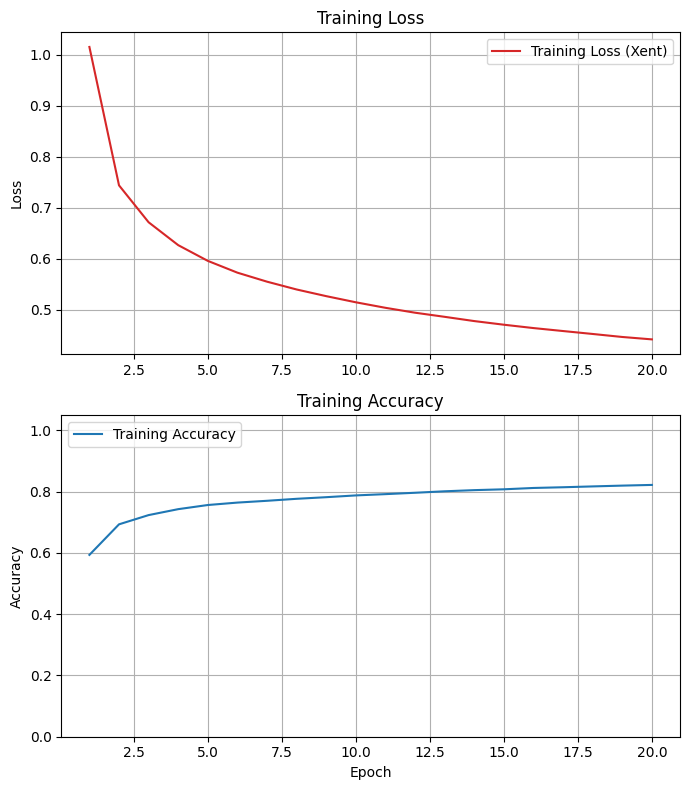

Final Training Loss:     0.4415
Final Training Accuracy: 0.8219
Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 594us/step - accuracy: 0.5456 - loss: 1.1854
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.6717 - loss: 0.8068
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - accuracy: 0.6975 - loss: 0.7356
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - accuracy: 0.7140 - loss: 0.6925
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - accuracy: 0.7272 - loss: 0.6606
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.7343 - loss: 0.6354
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - accuracy: 0.7441 - loss: 0.6149
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step - accuracy: 0.7516 - loss: 0.5986
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - accuracy: 0.7582 - loss: 0.5844
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.7644 - loss: 0.5719
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step 

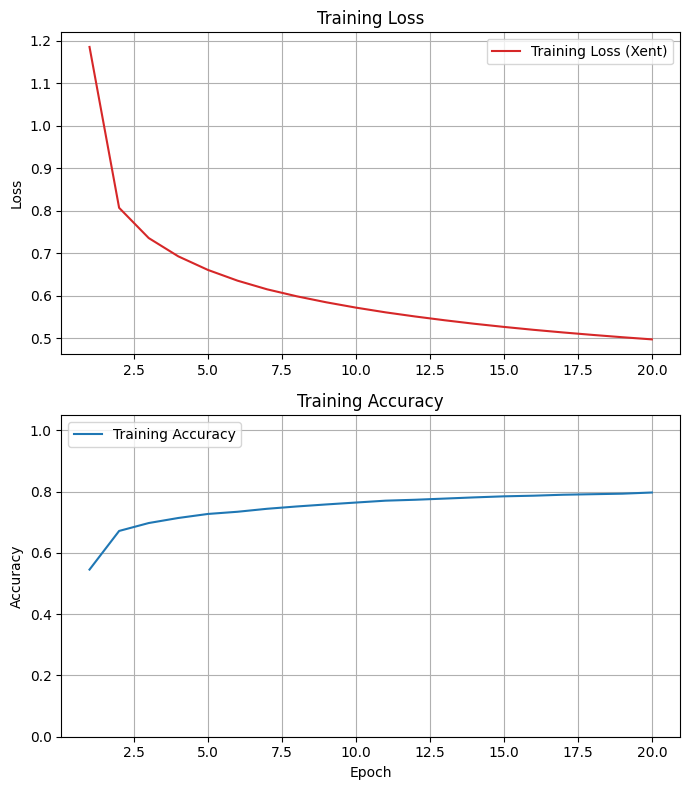

Final Training Loss:     0.4971
Final Training Accuracy: 0.7972
Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 606us/step - accuracy: 0.3643 - loss: 1.6657
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - accuracy: 0.5617 - loss: 1.2186
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - accuracy: 0.6046 - loss: 1.0038
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - accuracy: 0.6334 - loss: 0.9088
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - accuracy: 0.6562 - loss: 0.8597
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - accuracy: 0.6670 - loss: 0.8285
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step - accuracy: 0.6759 - loss: 0.8053
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - accuracy: 0.6837 - loss: 0.7866
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - accuracy: 0.6889 - loss: 0.7704
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - accuracy: 0.6949 - loss: 0.7560
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step 

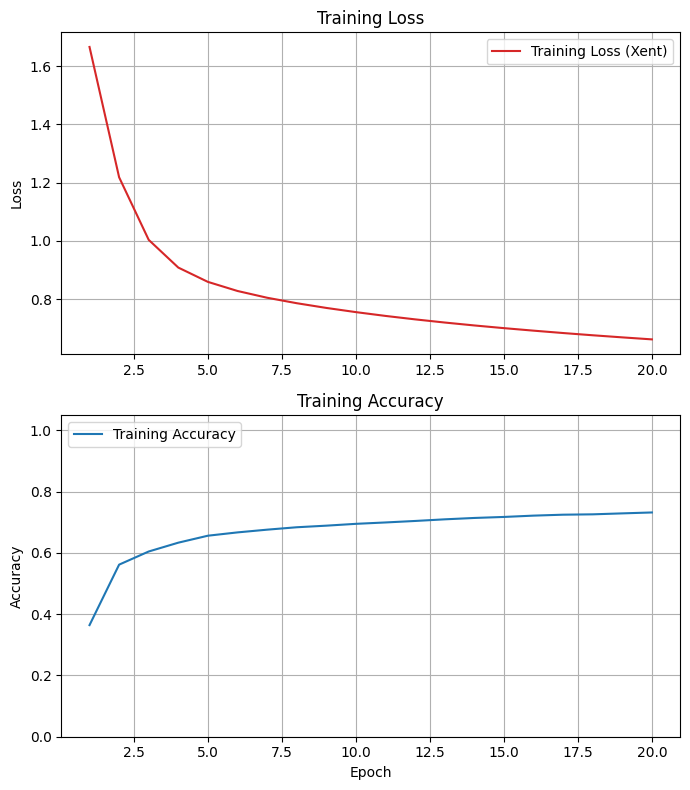

Final Training Loss:     0.6625
Final Training Accuracy: 0.7320
Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 611us/step - accuracy: 0.2398 - loss: 1.9434
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.4225 - loss: 1.5958
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.5194 - loss: 1.3353
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.5606 - loss: 1.1604
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - accuracy: 0.5834 - loss: 1.0535
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - accuracy: 0.6042 - loss: 0.9858
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.6189 - loss: 0.9402
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - accuracy: 0.6308 - loss: 0.9071
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - accuracy: 0.6393 - loss: 0.8817
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - accuracy: 0.6485 - loss: 0.8616
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step 

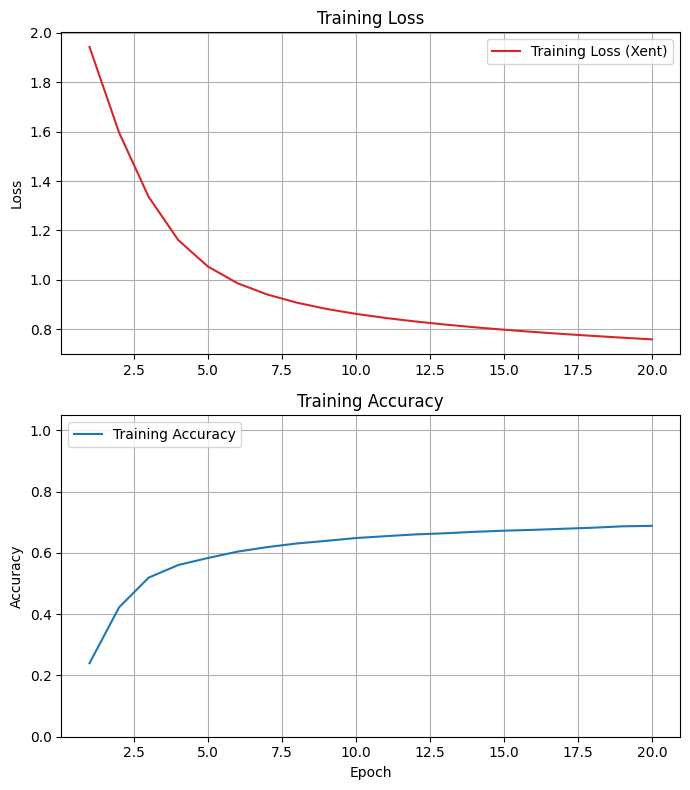

Final Training Loss:     0.7582
Final Training Accuracy: 0.6884
Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 633us/step - accuracy: 0.1530 - loss: 2.0792
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - accuracy: 0.1955 - loss: 1.9908
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - accuracy: 0.2330 - loss: 1.9163
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - accuracy: 0.2684 - loss: 1.8508
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - accuracy: 0.3064 - loss: 1.7907
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - accuracy: 0.3487 - loss: 1.7334
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - accuracy: 0.3873 - loss: 1.6780
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.4244 - loss: 1.6241
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - accuracy: 0.4569 - loss: 1.5714
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.4852 - loss: 1.5203
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step 

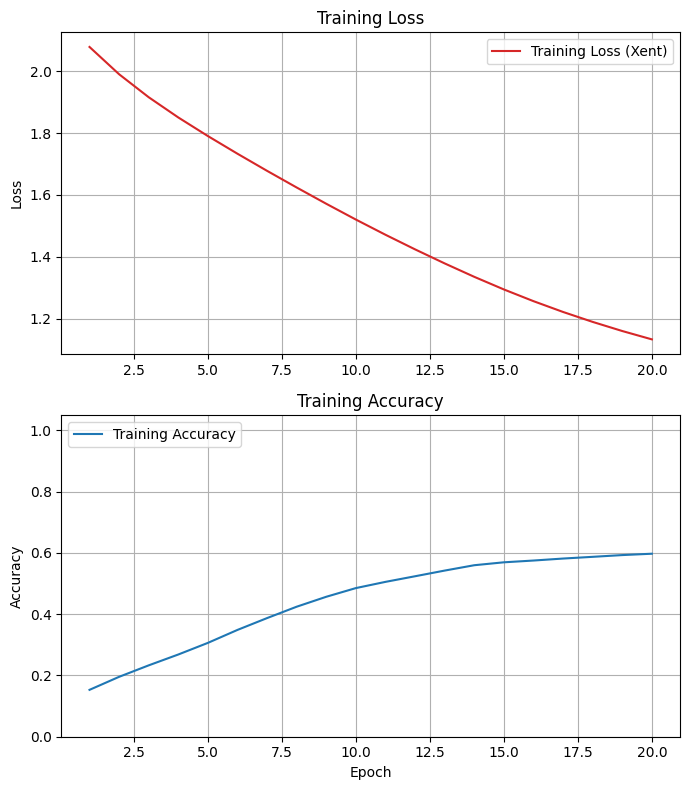

Final Training Loss:     1.1325
Final Training Accuracy: 0.5973


In [22]:
# Your code here
learning_rates = [
    1e-3,
    5e-4,
    1e-4,
    5e-5,
    1e-5,
]
final_epoch_training_acc = []
for learning_rate in learning_rates:
    model_baseline = Sequential(
        [
        Input(shape=(X_train.shape[1],)),     # Explicit input layer
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(len(classes), activation='softmax') # 1 neuron per unique class since softmax outputs a probability distribution
        ]
    )
    model_baseline.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model_baseline_history = model_baseline.fit(
        X_train_scaled, 
        y_train,
        epochs=n_epochs,
        batch_size=batch_size
    )
    plot_history(model_baseline_history)
    final_epoch_training_acc.append(model_baseline_history.history['accuracy'][-1])

In [23]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a = learning_rates[np.argmax(final_epoch_training_acc)]             # Replace 0.0 with your answer

In [24]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.0010


In [25]:
# Set a3b to the accuracy found by the best learning rate

a3b = max(final_epoch_training_acc)             # Replace 0.0 with your answer

In [26]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.8219


## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam. 

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.

In [27]:
batch_size, n_epochs

(32, 20)

Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 607us/step - accuracy: 0.6544 - loss: 0.8248
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.7175 - loss: 0.6747
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.7378 - loss: 0.6215
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - accuracy: 0.7545 - loss: 0.5909
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - accuracy: 0.7624 - loss: 0.5656
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - accuracy: 0.7771 - loss: 0.5341
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.7891 - loss: 0.5104
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - accuracy: 0.7985 - loss: 0.4853
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step - accuracy: 0.8104 - loss: 0.4647
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.8182 - loss: 0.4391
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - accuracy: 0.8288 - loss: 0.4177
Epoch 12/20
481/481 ━━━━━━━━━━

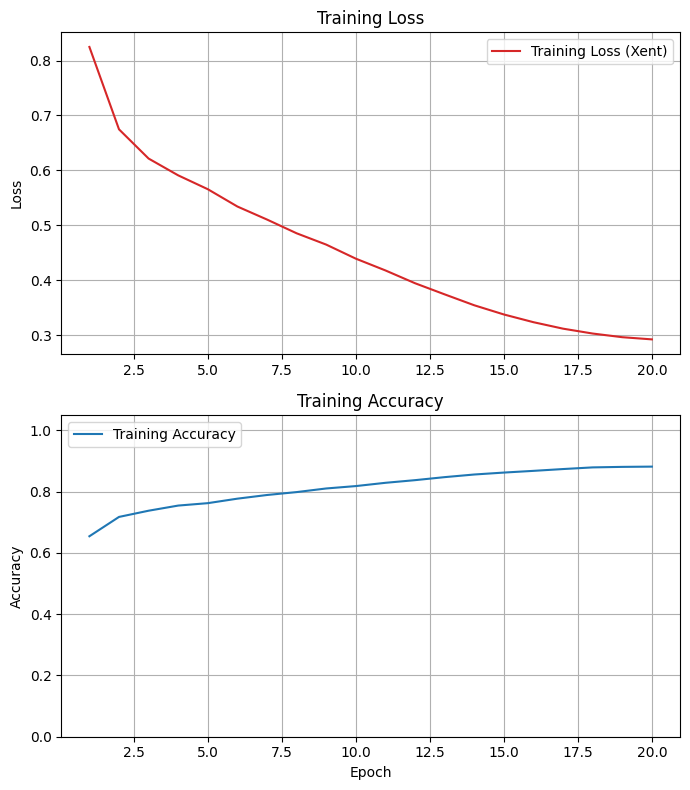

Final Training Loss:     0.2921
Final Training Accuracy: 0.8817
Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 597us/step - accuracy: 0.6551 - loss: 0.8345
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - accuracy: 0.7259 - loss: 0.6460
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - accuracy: 0.7530 - loss: 0.5911
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - accuracy: 0.7714 - loss: 0.5554
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - accuracy: 0.7813 - loss: 0.5332
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - accuracy: 0.7907 - loss: 0.5075
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - accuracy: 0.7978 - loss: 0.4890
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - accuracy: 0.8054 - loss: 0.4700
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - accuracy: 0.8122 - loss: 0.4510
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step - accuracy: 0.8209 - loss: 0.4335
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step 

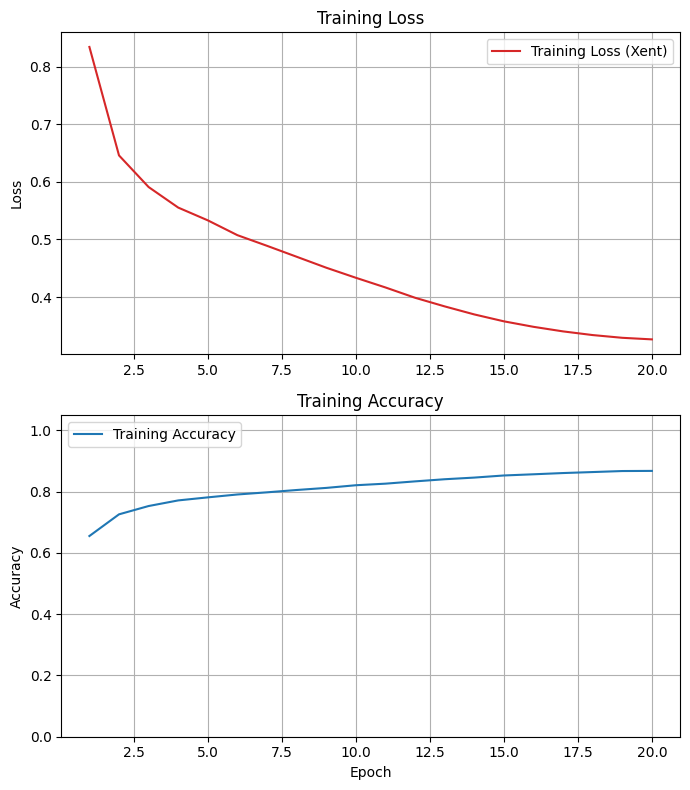

Final Training Loss:     0.3265
Final Training Accuracy: 0.8677
Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 581us/step - accuracy: 0.5936 - loss: 1.0243
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.6884 - loss: 0.7449
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - accuracy: 0.7196 - loss: 0.6757
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - accuracy: 0.7376 - loss: 0.6351
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - accuracy: 0.7472 - loss: 0.6064
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step - accuracy: 0.7585 - loss: 0.5843
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step - accuracy: 0.7662 - loss: 0.5664
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - accuracy: 0.7735 - loss: 0.5514
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - accuracy: 0.7791 - loss: 0.5389
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - accuracy: 0.7848 - loss: 0.5282
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step 

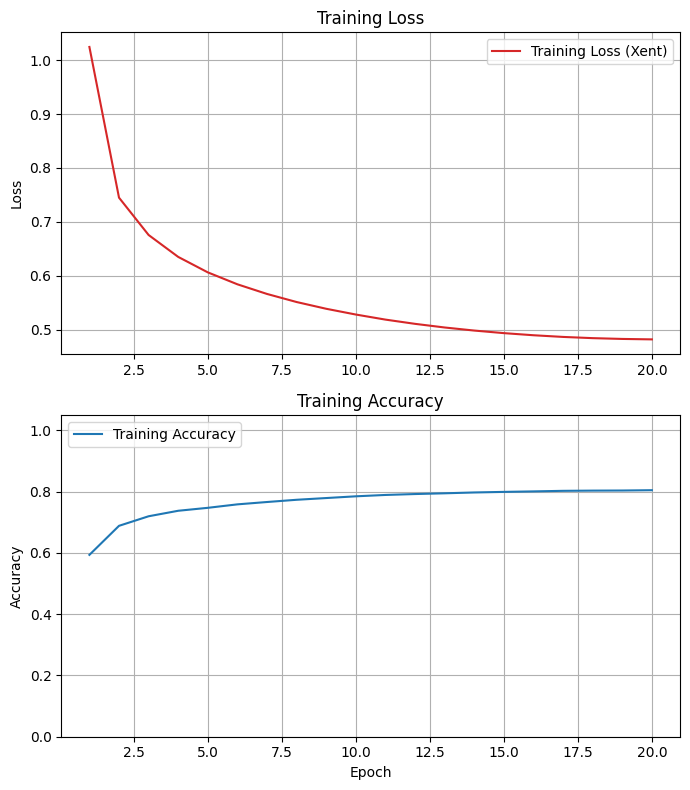

Final Training Loss:     0.4822
Final Training Accuracy: 0.8047
Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 608us/step - accuracy: 0.5424 - loss: 1.1680
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.6591 - loss: 0.8182
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - accuracy: 0.6925 - loss: 0.7441
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.7146 - loss: 0.6959
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.7296 - loss: 0.6610
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - accuracy: 0.7421 - loss: 0.6351
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.7505 - loss: 0.6153
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - accuracy: 0.7556 - loss: 0.5997
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step - accuracy: 0.7610 - loss: 0.5871
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - accuracy: 0.7653 - loss: 0.5768
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step 

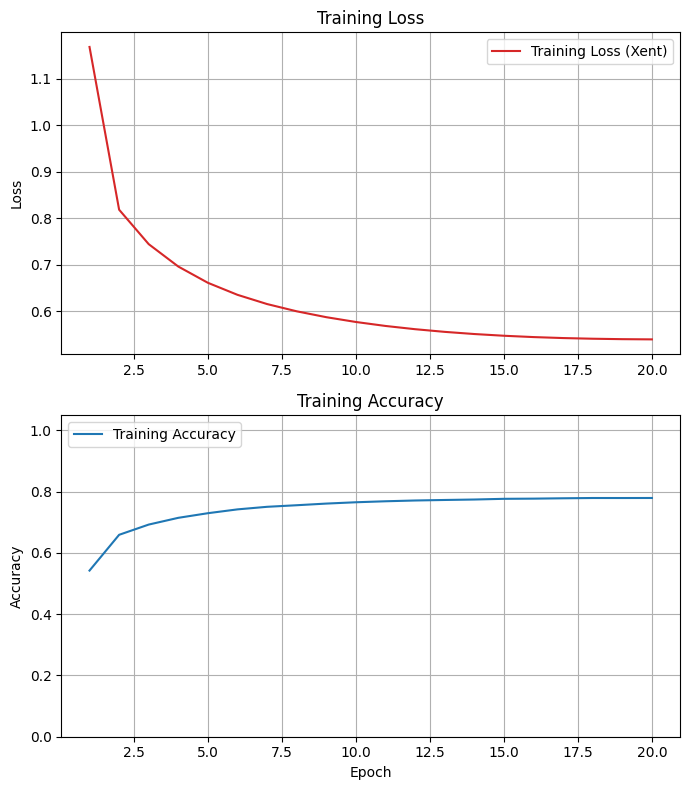

Final Training Loss:     0.5394
Final Training Accuracy: 0.7793
Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 602us/step - accuracy: 0.3703 - loss: 1.7136
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.5375 - loss: 1.2938
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - accuracy: 0.6002 - loss: 1.0689
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - accuracy: 0.6273 - loss: 0.9541
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - accuracy: 0.6492 - loss: 0.8922
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.6583 - loss: 0.8545
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - accuracy: 0.6681 - loss: 0.8286
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.6747 - loss: 0.8103
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.6796 - loss: 0.7965
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.6828 - loss: 0.7856
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step 

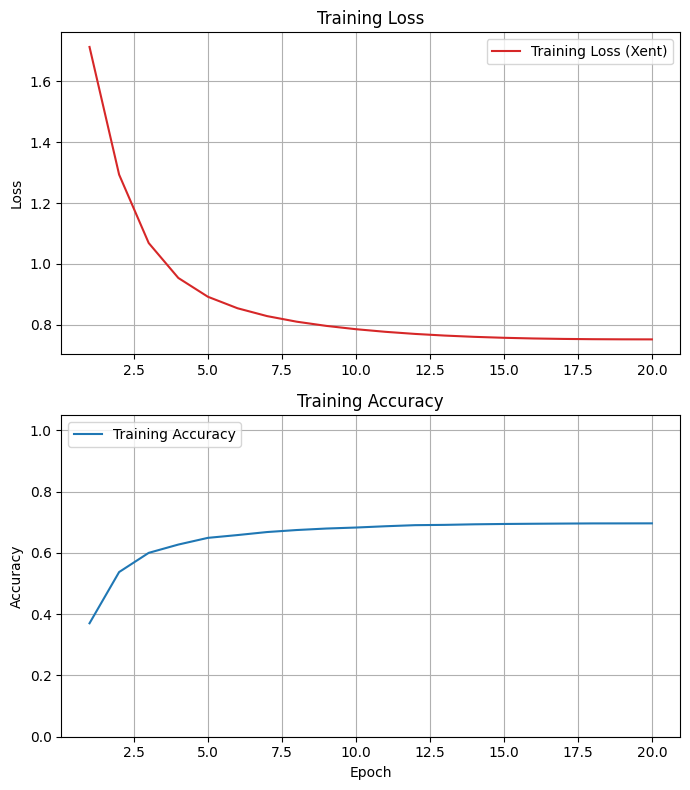

Final Training Loss:     0.7521
Final Training Accuracy: 0.6965


In [28]:
# Compute the number of steps (batches) per epoch

steps_per_epoch = int(np.ceil(len(X_train_scaled) / batch_size))

# Total number of training steps (needed for per-step schedulers like CosineDecay)

total_steps = n_epochs * steps_per_epoch

initial_lrs = [
    1e-2, 
    5e-3, 
    1e-3,
    5e-4, 
    1e-4
]
final_epoch_training_acc = []
for initial_lr in initial_lrs:
    # CosineDecay schedule (per-step)
    lr_schedule = CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=total_steps,
        alpha=0.0  # Final LR = 0
    )

    model_baseline = Sequential(
        [
        Input(shape=(X_train.shape[1],)),     # Explicit input layer
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(len(classes), activation='softmax') # 1 neuron per unique class since softmax outputs a probability distribution
        ]
    )
    model_baseline.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model_baseline_history = model_baseline.fit(
        X_train_scaled, 
        y_train,
        epochs=n_epochs,
        batch_size=batch_size
    )
    plot_history(model_baseline_history)
    final_epoch_training_acc.append(model_baseline_history.history['accuracy'][-1])

In [41]:
final_epoch_training_acc

[0.881687581539154,
 0.8677111268043518,
 0.8047195076942444,
 0.7793018221855164,
 0.6964831352233887]

In [29]:
# Set a4a to the initial learning rate which produced the best accuracy

a4a = initial_lrs[np.argmax(final_epoch_training_acc)]             # Replace 0.0 with your answer

In [30]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.0100


In [31]:
# Set a4b to the best accuracy found

a4b = np.max(final_epoch_training_acc)             # Replace 0.0 with your answer

In [32]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.8817


## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture. 

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the test set
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

Epoch 1/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 3s 590us/step - accuracy: 0.6257 - loss: 0.9110
Epoch 2/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 585us/step - accuracy: 0.6770 - loss: 0.7863
Epoch 3/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 578us/step - accuracy: 0.6990 - loss: 0.7387
Epoch 4/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 584us/step - accuracy: 0.7145 - loss: 0.7128
Epoch 5/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 579us/step - accuracy: 0.7239 - loss: 0.6788
Epoch 6/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 582us/step - accuracy: 0.7377 - loss: 0.6549
Epoch 7/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 579us/step - accuracy: 0.7447 - loss: 0.6497
Epoch 8/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 566us/step - accuracy: 0.7556 - loss: 0.6104
Epoch 9/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 576us/step - accuracy: 0.7586 - loss: 0.6426
Epoch 10/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 566us/step - accuracy: 0.7690 - loss: 0.5807
Epoch 11/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 2s 571us/step - accuracy: 0.7795 - loss: 0.5478
Epoch 12

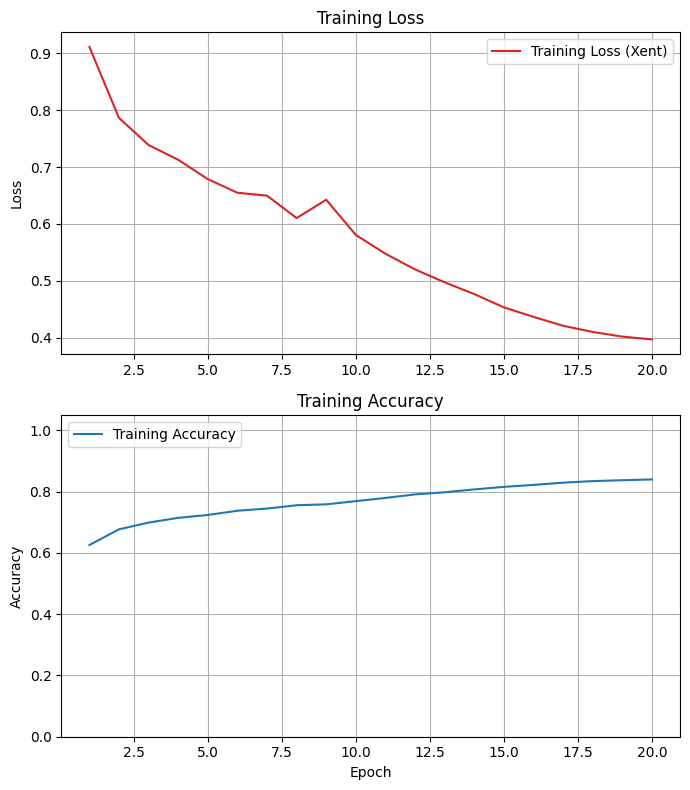

Final Training Loss:     0.3973
Final Training Accuracy: 0.8398


In [49]:
"""

Varying batch size our best result was 0.7734 training accuracy with batch_size = 4

Varying learning_rate our best result was training accuracy 0.8219 with 0.0010 learning_rate

Using learning rate scheduler our best result was 0.8817 training accuracy with 0.0100 initial learning rate

Based on these results I plan to use the learning rate scheduler with 0.0100 initial learning rate with a batch_size = 4
"""

final_batch_size = 4
final_initial_lr = 1e-2

# Compute the number of steps (batches) per epoch
steps_per_epoch = int(np.ceil(len(X_train_scaled) / final_batch_size))

# Total number of training steps (needed for per-step schedulers like CosineDecay)
total_steps = n_epochs * steps_per_epoch

# CosineDecay schedule (per-step)
lr_schedule = CosineDecay(
    initial_learning_rate=final_initial_lr,
    decay_steps=total_steps,
    alpha=0.0  # Final LR = 0
)

model = Sequential(
    [
    Input(shape=(X_train.shape[1],)),     # Explicit input layer
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(len(classes), activation='softmax') # 1 neuron per unique class since softmax outputs a probability distribution
    ]
)
model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_history = model.fit(
    X_train_scaled, 
    y_train,
    epochs=n_epochs,
    batch_size=final_batch_size
)
plot_history(model_history)

training_accuracy = model_history.history['accuracy'][-1]

In [52]:
# Set a5a to the best training accuracy found by your best model

a5a = training_accuracy             # Replace 0.0 with your answer

In [53]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.8398


In [55]:
results = model.evaluate(X_test_scaled, y_test, verbose=1)
test_loss = results[0]
test_accuracy = results[1]
test_accuracy, test_loss

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - accuracy: 0.8034 - loss: 0.5300


(0.8034321665763855, 0.5300043821334839)

In [56]:
# Set a5b to the test accuracy found by your best model

a5b = test_accuracy             # Replace 0.0 with your answer

In [57]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8034


## Reflection Questions (ungraded)

1. We trained on a perfectly balanced \~3.3% subset.
   If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?

2. **Batch size trade-offs.**
   With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?

3. **More epochs, same LR.**
    If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc? 

4. **Epochs vs. LR.**
   It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?

1a. I expect training time to increase with more training samples since there are more data points to evaluate per forward and backward pass. Each epoch must pass through all datapoints so they increase linearly together.

1b. I expect the best batch size could increase 

1c. I expect the best learning rate could also increase since with a larger batch size we generally also increase learning rate. We will be more confident in the gradients calculated at each step and can move further without overshooting the target

# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


Shape: (19229, 55)

Class distribution:
 Cover_Type
3    0.142857
2    0.142857
6    0.142857
5    0.142857
4    0.142857
1    0.142857
0    0.142857
Name: proportion, dtype: float64


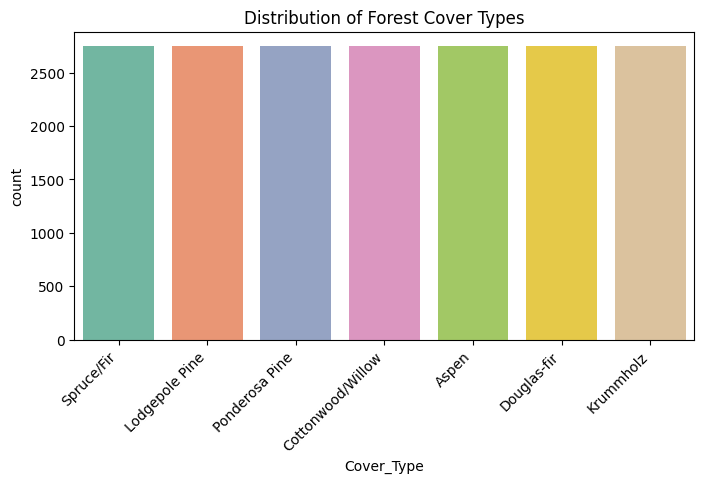

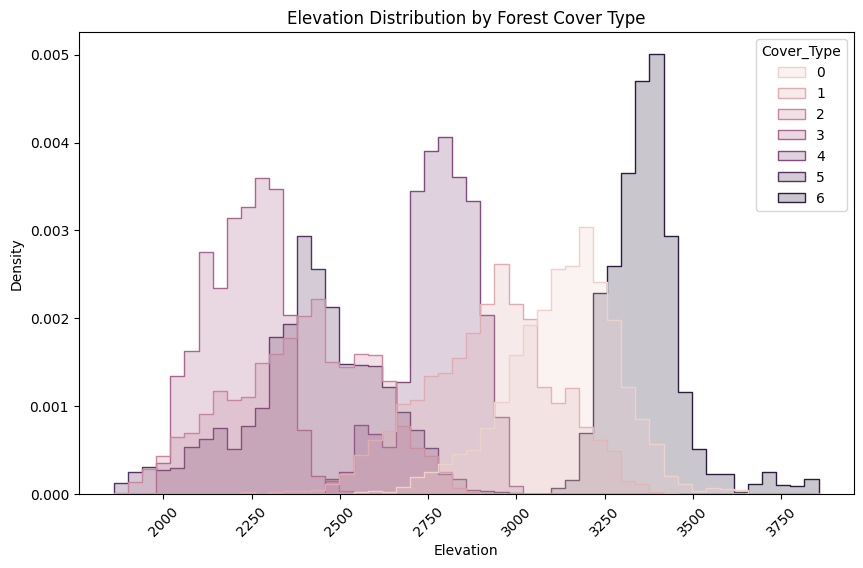

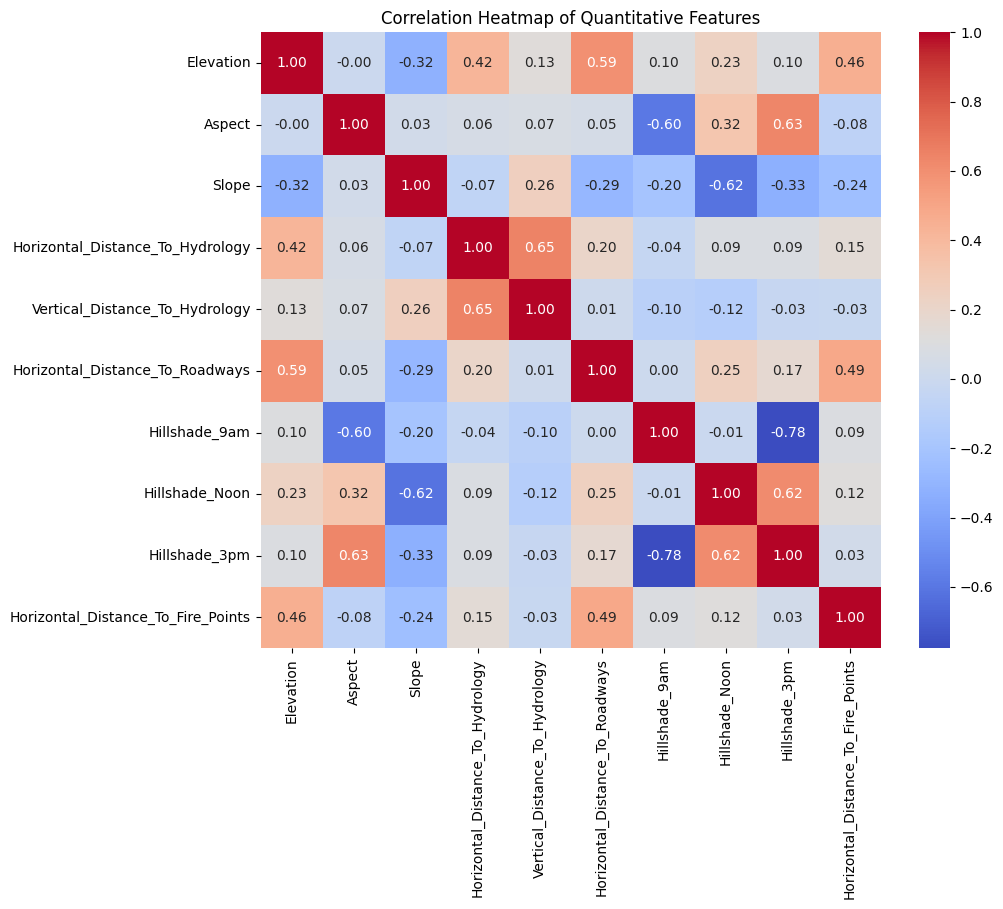

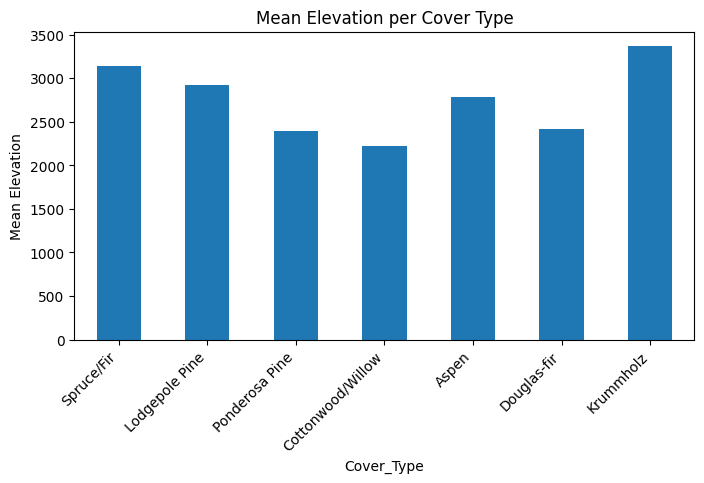

In [38]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,8))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.show()
